# Lab 1 — Binary Independence Model & BM25
**AICL 316 | Information Retrieval | Unit 5**

---

In this lab you will implement two probabilistic ranking models from scratch — BIM and BM25. By the end you should understand not just how the formulas work, but *why* they are designed that way.

**Part A** covers BIM. **Part B** covers BM25, which is essentially BIM with two important improvements.

Estimated time: about 60 minutes. Work through the cells in order — later cells depend on functions defined earlier.


### Setup — run this before anything else

In [ ]:
import math
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['font.size']        = 11

print("Ready!")


 Ready!


---
## Part A — Binary Independence Model (BIM)

BIM is the starting point for probabilistic IR. The central question it asks is simple: *for this query term, does it appear more often in relevant documents or non-relevant ones?*

If a term keeps turning up in relevant documents but is rare elsewhere, it is a strong signal. If it appears equally everywhere, it tells you nothing.

### Formulas you need

**Estimate how likely a term is in each group** (the 0.5 is added to avoid dividing by zero):

$$\hat{p}_t = \frac{s + 0.5}{S + 1} \qquad \hat{q}_t = \frac{df - s + 0.5}{N - S + 1}$$

**Term weight** — how discriminating is this term?

$$c_t = \log \frac{\hat{p}_t \;(1 - \hat{q}_t)}{\hat{q}_t \;(1 - \hat{p}_t)}$$

**RSV — the final document score:**

$$\text{RSV}(d, q) = \sum_{t \in q \cap d} c_t$$

Only terms that appear in **both** the query and the document contribute to the score.

| Symbol | What it means |
|--------|---------------|
| N | Total documents |
| S | Relevant documents |
| df | Documents containing term t |
| s | Relevant documents containing term t |
| p̂ₜ | Estimated P(term present \| document is relevant) |
| q̂ₜ | Estimated P(term present \| document is non-relevant) |
| cₜ | Term weight |
| RSV | Document score |


### A1 — The collection we're working with

In [ ]:
# 10 computing documents
corpus = {
    'D1' : ['machine','learning','algorithms','neural','data'],
    'D2' : ['database','sql','query','data','storage'],
    'D3' : ['neural','network','deep','machine','learning'],
    'D4' : ['python','web','html','database','javascript'],
    'D5' : ['information','retrieval','query','document','ranking'],
    'D6' : ['language','processing','neural','machine','text'],
    'D7' : ['network','protocol','data','packet','internet'],
    'D8' : ['process','memory','system','kernel','storage'],
    'D9' : ['machine','learning','application','data','real'],
    'D10': ['data','mining','machine','learning','patterns'],
}

QUERY    = ['machine', 'learning', 'data']
RELEVANT = {'D1','D3','D6','D9','D10'}

N = len(corpus)
S = len(RELEVANT)

print(f"Total documents  N = {N}")
print(f"Relevant docs    S = {S}  →  {sorted(RELEVANT)}")
print(f"Query            = {QUERY}")
print()

# Binary vectors for query terms
print("Binary document vectors  (1 = present,  0 = absent):")
print(f"{'Doc':<5}", end="")
for t in QUERY:
    print(f"  {t:>10}", end="")
print("  | Relevant?")
print("─" * 55)
for doc, words in corpus.items():
    print(f"{doc:<5}", end="")
    for t in QUERY:
        print(f"  {1 if t in words else 0:>10}", end="")
    print(f"  | {'Relevant' if doc in RELEVANT else 'Not Relevant'}")


Total documents  N = 10
Relevant docs    S = 5  →  ['D1', 'D10', 'D3', 'D6', 'D9']
Query            = ['machine', 'learning', 'data']

Binary document vectors  (1 = present,  0 = absent):
Doc       machine    learning        data  | Relevant?
───────────────────────────────────────────────────────
D1              1           1           1  | Relevant
D2              0           0           1  | Not Relevant
D3              1           1           0  | Relevant
D4              0           0           0  | Not Relevant
D5              0           0           0  | Not Relevant
D6              1           0           0  | Relevant
D7              0           0           1  | Not Relevant
D8              0           0           0  | Not Relevant
D9              1           1           1  | Relevant
D10             1           1           1  | Relevant


### A2 — Building the contingency table

Before we can compute any probabilities, we need to count. For each query term, we split the collection into a 2×2 table:

```
                 | term present  | term absent  | Total
  Relevant       |      s        |    S - s     |   S
  Non-relevant   |    df - s     |  N-df-S+s    |  N-S
  Total          |      df       |    N - df    |   N
```

Run the cell and check the numbers make sense — every row and column should add up correctly.


In [ ]:
def contingency(term, corpus, relevant):
    s  = sum(1 for doc,words in corpus.items() if doc in relevant and term in words)
    df = sum(1 for words in corpus.values() if term in words)
    return s, len(relevant), df, len(corpus)

print(f"{'Term':<12} | {'s':>4} {'S-s':>5} | {'df-s':>6} {'N-df-S+s':>10} | {'df':>5} {'N-df':>6}")
print("─" * 58)
for t in QUERY:
    s, S_, df, N_ = contingency(t, corpus, RELEVANT)
    print(f"{t:<12} | {s:>4} {S_-s:>5} | {df-s:>6} {N_-df-S_+s:>10} | {df:>5} {N_-df:>6}")


Term         |    s   S-s |   df-s   N-df-S+s |    df   N-df
──────────────────────────────────────────────────────────
machine      |    5     0 |      0          5 |     5      5
learning     |    4     1 |      0          5 |     4      6
data         |    3     2 |      2          3 |     5      5


### A3 — Computing term weights

Now we use those counts to estimate p̂ₜ and q̂ₜ, then plug them into the weight formula.

Notice the "signal strength" column — it gives you an intuition for what the weight actually means. A high positive weight means "this term is a strong clue that the document is relevant". A weight near zero means "this term appears everywhere, it doesn't help us discriminate". A negative weight is interesting — it means the term actually appears *more* in non-relevant documents.


In [ ]:
def bim_weight(term, corpus, relevant):
    s, S_, df, N_ = contingency(term, corpus, relevant)
    p_hat = (s  + 0.5) / (S_      + 1)   # P(t | relevant)
    q_hat = (df - s + 0.5) / (N_ - S_ + 1)  # P(t | non-relevant)
    c_t   = math.log(p_hat * (1 - q_hat) / (q_hat * (1 - p_hat)))
    return c_t, p_hat, q_hat

print(f"{'Term':<12} | {'p̂t':>7} {'q̂t':>7} | {'Weight cₜ':>10} | Signal strength")
print("─" * 60)
term_weights = {}
for t in QUERY:
    c_t, p_hat, q_hat = bim_weight(t, corpus, RELEVANT)
    term_weights[t] = c_t
    strength = "■■■ Strong" if c_t > 2 else ("■■  Medium" if c_t > 0.5 else "■   Weak")
    print(f"{t:<12} | {p_hat:>7.4f} {q_hat:>7.4f} | {c_t:>10.4f} | {strength}")

print()
print("► High cₜ  →  term is common in RELEVANT docs and rare elsewhere  →  strong signal")
print("► Low cₜ   →  term appears equally in both groups  →  weak signal")
print("► Negative →  term is MORE common in NON-RELEVANT docs  →  misleading signal")


Term         |     p̂t     q̂t |  Weight cₜ | Signal strength
────────────────────────────────────────────────────────────
machine      |  0.9167  0.0833 |     4.7958 | ■■■ Strong
learning     |  0.7500  0.0833 |     3.4965 | ■■■ Strong
data         |  0.5833  0.4167 |     0.6729 | ■■  Medium

► High cₜ  →  term is common in RELEVANT docs and rare elsewhere  →  strong signal
► Low cₜ   →  term appears equally in both groups  →  weak signal
► Negative →  term is MORE common in NON-RELEVANT docs  →  misleading signal


### A4 — Scoring and ranking documents

RSV is just a sum — add up the weights of every query term that the document contains. A document missing a term simply gets zero contribution from it.

Look at the output carefully. Some documents match two query terms, some match one, some match none. You can see exactly why each document ends up where it does.


In [ ]:
def compute_rsv(words, query, weights):
    score   = 0.0
    matched = []
    for t in query:
        if t in words:
            score += weights[t]
            matched.append(t)
    return score, matched

print(f"{'Doc':<5} | {'RSV':>8} | {'Matched terms':<32} | Relevant?")
print("─" * 62)
scores = {}
for doc, words in corpus.items():
    rsv, matched = compute_rsv(words, QUERY, term_weights)
    scores[doc]  = rsv
    rel = "✓ YES" if doc in RELEVANT else "  no"
    print(f"{doc:<5} | {rsv:>8.4f} | {str(matched):<32} | {rel}")

ranked = sorted(scores, key=lambda d: scores[d], reverse=True)
print()
print("FINAL RANKING:")
for i, doc in enumerate(ranked, 1):
    rel = "✓ RELEVANT" if doc in RELEVANT else ""
    print(f"  #{i:>2}  {doc:<5}  score = {scores[doc]:>7.4f}   {rel}")


Doc   |      RSV | Matched terms                    | Relevant?
──────────────────────────────────────────────────────────────
D1    |   8.9652 | ['machine', 'learning', 'data']  | ✓ YES
D2    |   0.6729 | ['data']                         |   no
D3    |   8.2923 | ['machine', 'learning']          | ✓ YES
D4    |   0.0000 | []                               |   no
D5    |   0.0000 | []                               |   no
D6    |   4.7958 | ['machine']                      | ✓ YES
D7    |   0.6729 | ['data']                         |   no
D8    |   0.0000 | []                               |   no
D9    |   8.9652 | ['machine', 'learning', 'data']  | ✓ YES
D10   |   8.9652 | ['machine', 'learning', 'data']  | ✓ YES

FINAL RANKING:
  # 1  D1     score =  8.9652   ✓ RELEVANT
  # 2  D9     score =  8.9652   ✓ RELEVANT
  # 3  D10    score =  8.9652   ✓ RELEVANT
  # 4  D3     score =  8.2923   ✓ RELEVANT
  # 5  D6     score =  4.7958   ✓ RELEVANT
  # 6  D2     score =  0.6729   
  # 7  D7     

### A5 — Plots

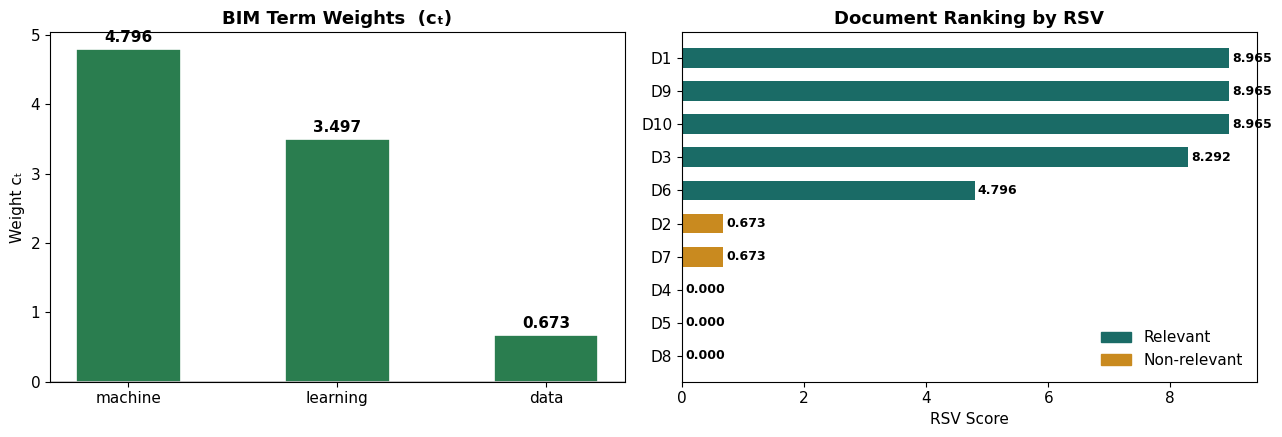

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left — term weights
ax = axes[0]
terms = list(term_weights)
vals  = [term_weights[t] for t in terms]
cols  = ['#2a7d4f' if v > 0 else '#c0392b' for v in vals]
bars  = ax.bar(terms, vals, color=cols, width=0.5, edgecolor='white', linewidth=1.2)
ax.axhline(0, color='black', lw=1)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2,
            v + 0.1 if v >= 0 else v - 0.3,
            f'{v:.3f}', ha='center', fontweight='bold')
ax.set_title('BIM Term Weights  (cₜ)', fontsize=13, fontweight='bold')
ax.set_ylabel('Weight cₜ')

# Right — document RSV scores
ax2  = axes[1]
docs_ord  = sorted(scores, key=lambda d: scores[d], reverse=True)
score_vals = [scores[d] for d in docs_ord]
bar_cols   = ['#1a6b66' if d in RELEVANT else '#c98a1f' for d in docs_ord]
ax2.barh(docs_ord[::-1], score_vals[::-1], color=bar_cols[::-1], height=0.6)
for i, (doc, v) in enumerate(zip(docs_ord[::-1], score_vals[::-1])):
    ax2.text(v + 0.05, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=9)
ax2.legend(handles=[mpatches.Patch(color='#1a6b66', label='Relevant'),
                    mpatches.Patch(color='#c98a1f', label='Non-relevant')], frameon=False)
ax2.set_title('Document Ranking by RSV', fontsize=13, fontweight='bold')
ax2.set_xlabel('RSV Score')

plt.tight_layout()
plt.show()


### Tasks — Part A

**Task A1**

Fill in the contingency table for the term **'machine'** using the numbers printed above.

|  | term present | term absent | Total |
|--|-------------|-------------|-------|
| Relevant | s = ___ | S − s = ___ | S = 5 |
| Non-relevant | df − s = ___ | N−df−S+s = ___ | N−S = 5 |
| Total | df = ___ | N − df = ___ | N = 10 |

---

**Task A2**

D3 contains: `neural, network, deep, machine, learning`. Query is: `machine, learning, data`.

Which of those query terms are actually in D3? Work out the RSV by hand:

$$\text{RSV}(D3) = c_{machine} + c_{learning} = \_\_\_ + \_\_\_ = \_\_\_$$

---

**Task A3**

What does a **negative** term weight mean? If a document contains a negatively-weighted term, does its RSV go up or down? Can you think of a real-world example of a word that might have a negative weight?

*Your answer:*


--- ## Solution to Tasks — Part A

**Task A1 — Contingency table for 'machine'**

Using the output from the `contingency` function for 'machine':

`s = 5`, `S-s = 0`, `df-s = 0`, `N-df-S+s = 5`, `df = 5`, `N-df = 5`

|  | term present | term absent | Total |
|--|-------------|-------------|-------|
| Relevant | s = 5 | S − s = 0 | S = 5 |
| Non-relevant | df − s = 0 | N−df−S+s = 5 | N−S = 5 |
| Total | df = 5 | N − df = 5 | N = 10 |

---

**Task A2 — RSV for D3**

D3 contains: `neural, network, deep, machine, learning`.
Query is: `machine, learning, data`.

Query terms present in D3 are: `machine`, `learning`.

From the `bim_weight` output:
`c_machine = 4.7958`
`c_learning = 3.4965`

$$\text{RSV}(D3) = c_{machine} + c_{learning} = 4.7958 + 3.4965 = 8.2923$$

---

**Task A3 — Negative term weight**

Your answer:
A **negative term weight** means that the term appears more frequently in non-relevant documents than in relevant documents. If a document contains a negatively-weighted term, its RSV (document score) will **go down**, as the negative weight will reduce the total sum.

A real-world example of a word that might have a negative weight could be a very common, generic word like "the" or "a" if we were trying to find specialized documents. While these words appear everywhere, they don't help discriminate relevant from non-relevant documents, and if they somehow appeared *more* in non-relevant documents in a specific context (perhaps due to longer, less focused non-relevant documents), they could hypothetically receive a slight negative weight. A more concrete example could be a term like "spam" in a query about emails if the dataset of relevant emails is clean and non-relevant emails are mostly spam; the presence of "spam" would strongly suggest non-relevance.

---
## Part B — Okapi BM25

BIM works, but it ignores two things that clearly matter in practice:

1. A document that says "machine" ten times is probably *more* about machine learning than one that says it once. BIM can't tell the difference.
2. A 5,000-word document will naturally contain more terms than a 50-word abstract — we should adjust for that.

BM25 fixes both. The core formula looks more complex, but it's still doing the same thing as BIM at heart — it just adds a smarter term frequency component on top.

$$\text{BM25}(d, q) = \sum_{t \in q} \text{IDF}(t) \times \frac{tf_{t,d}\,(k_1 + 1)}{tf_{t,d} + k_1\!\left(1 - b + b \cdot \dfrac{|d|}{\text{avgdl}}\right)}$$

$$\text{IDF}(t) = \log\!\left(\frac{N - df + 0.5}{df + 0.5} + 1\right)$$

Two parameters control the behaviour:

| Parameter | Typical value | What it does |
|-----------|--------------|--------------|
| k₁ | 1.2 – 2.0 | Controls TF saturation — how fast extra occurrences stop mattering |
| b | 0.75 | Controls length normalisation — how much long documents are penalised |

One more thing worth noting: if you set k₁ = 0, the TF part collapses to a constant and you basically get BIM back. BM25 is a generalisation of BIM, not a completely different model.


### B1 — A richer collection

This corpus has repeated words on purpose. If we used the binary corpus from Part A, BIM and BM25 would give the same ranking — there'd be nothing interesting to compare. Here you can see that D1 mentions "machine" three times and D2 has "deep" twice, so term frequency actually varies.


In [ ]:
# Documents with repeated words so tf actually varies
corpus_bm = {
    'D1': 'machine learning algorithms neural machine learning deep machine'.split(),
    'D2': 'deep learning neural network image classification deep neural learning'.split(),
    'D3': 'information retrieval boolean model index ranking query information'.split(),
    'D4': 'language processing text mining sentiment analysis machine learning'.split(),
    'D5': 'database sql query optimization index database table join query'.split(),
    'D6': 'neural network backpropagation learning gradient neural network deep'.split(),
    'D7': 'web information retrieval search engine ranking document index'.split(),
    'D8': 'probability statistics bayesian inference prior posterior probability'.split(),
}

QUERY_BM    = ['machine', 'learning']
RELEVANT_BM = {'D1', 'D2', 'D6'}

avgdl = sum(len(w) for w in corpus_bm.values()) / len(corpus_bm)
print(f"Average document length (avgdl) = {avgdl:.1f} words")
print()
print(f"{'Doc':<5} | {'Length':>7} | {'machine':>8} | {'learning':>9}")
print("─" * 38)
for doc, words in corpus_bm.items():
    c = Counter(words)
    print(f"{doc:<5} | {len(words):>7} | {c.get('machine',0):>8} | {c.get('learning',0):>9}")


Average document length (avgdl) = 8.1 words

Doc   |  Length |  machine |  learning
──────────────────────────────────────
D1    |       8 |        3 |         2
D2    |       9 |        0 |         2
D3    |       8 |        0 |         0
D4    |       8 |        1 |         1
D5    |       9 |        0 |         0
D6    |       8 |        0 |         1
D7    |       8 |        0 |         0
D8    |       7 |        0 |         0


### B2 — BM25 implementation

The code below implements BM25 in three short functions. `bm25_idf` computes the IDF for one term. `bm25_score` loops over query terms and combines IDF with the normalised TF component. Read through it once before running — it follows the formula directly.


In [ ]:
def bm25_idf(term, corpus_dict):
    N_  = len(corpus_dict)
    df  = sum(1 for w in corpus_dict.values() if term in w)
    return math.log((N_ - df + 0.5) / (df + 0.5) + 1)

def bm25_score(query_terms, doc_words, corpus_dict, k1=1.5, b=0.75):
    N_      = len(corpus_dict)
    avgdl_  = sum(len(d) for d in corpus_dict.values()) / N_
    doc_len = len(doc_words)
    counts  = Counter(doc_words)
    score   = 0.0
    for t in query_terms:
        tf = counts.get(t, 0)
        if tf == 0:
            continue
        idf           = bm25_idf(t, corpus_dict)
        length_factor = 1 - b + b * (doc_len / avgdl_)
        tf_component  = tf * (k1 + 1) / (tf + k1 * length_factor)
        score        += idf * tf_component
    return score

# Score all documents
print(f"{'Doc':<5} | {'BM25 Score':>10} | {'Length':>7} | {'machine':>8} | {'learning':>9} | Relevant?")
print("─" * 65)
bm_scores = {}
for doc, words in corpus_bm.items():
    sc = bm25_score(QUERY_BM, words, corpus_bm)
    bm_scores[doc] = sc
    c   = Counter(words)
    rel = "✓ YES" if doc in RELEVANT_BM else "  no"
    print(f"{doc:<5} | {sc:>10.4f} | {len(words):>7} | {c.get('machine',0):>8} | {c.get('learning',0):>9} | {rel}")

ranked_bm = sorted(bm_scores, key=lambda d: bm_scores[d], reverse=True)
print()
print("RANKING:", " > ".join(ranked_bm))


Doc   | BM25 Score |  Length |  machine |  learning | Relevant?
─────────────────────────────────────────────────────────────────
D1    |     3.1383 |       8 |        3 |         2 | ✓ YES
D2    |     0.9571 |       9 |        0 |         2 | ✓ YES
D3    |     0.0000 |       8 |        0 |         0 |   no
D4    |     1.9878 |       8 |        1 |         1 |   no
D5    |     0.0000 |       9 |        0 |         0 |   no
D6    |     0.6980 |       8 |        0 |         1 | ✓ YES
D7    |     0.0000 |       8 |        0 |         0 |   no
D8    |     0.0000 |       7 |        0 |         0 |   no

RANKING: D1 > D4 > D2 > D6 > D3 > D5 > D7 > D8


### B3 — Walking through one calculation

It helps to see the arithmetic for a single term before trusting the loop. This cell traces every step for D1 and the term "machine" so you can follow along and check it against the formula.


In [ ]:
# Trace the full BM25 calculation for D1, term = 'machine'
print("BM25 step-by-step  |  Document D1,  term = 'machine'")
print("=" * 52)

t       = 'machine'
doc     = 'D1'
k1, b   = 1.5, 0.75
words_d = corpus_bm[doc]

tf      = Counter(words_d).get(t, 0)
N_      = len(corpus_bm)
df      = sum(1 for w in corpus_bm.values() if t in w)
avgdl_  = sum(len(w) for w in corpus_bm.values()) / N_
doc_len = len(words_d)

idf           = math.log((N_ - df + 0.5) / (df + 0.5) + 1)
length_factor = 1 - b + b * (doc_len / avgdl_)
tf_component  = tf * (k1 + 1) / (tf + k1 * length_factor)
contribution  = idf * tf_component

print(f"  tf   (how many times 'machine' appears in D1)  = {tf}")
print(f"  df   (documents that contain 'machine')        = {df}")
print(f"  N    (total documents)                         = {N_}")
print(f"  avgdl (average document length)                = {avgdl_:.2f}")
print(f"  |d|  (length of D1)                            = {doc_len}")
print()
print(f"  Step 1  IDF  = log(({N_}-{df}+0.5)/({df}+0.5) + 1)")
print(f"               = log({(N_-df+0.5)/(df+0.5):.3f} + 1) = {idf:.4f}")
print()
print(f"  Step 2  length_factor = 1 - {b} + {b}*({doc_len}/{avgdl_:.2f})")
print(f"                        = {length_factor:.4f}")
print()
print(f"  Step 3  tf_component  = {tf}*({k1}+1) / ({tf} + {k1}*{length_factor:.4f})")
print(f"                        = {tf*(k1+1):.3f} / {tf + k1*length_factor:.4f}")
print(f"                        = {tf_component:.4f}")
print()
print(f"  Step 4  contribution  = IDF * tf_component")
print(f"                        = {idf:.4f} * {tf_component:.4f} = {contribution:.4f}")


BM25 step-by-step  |  Document D1,  term = 'machine'
  tf   (how many times 'machine' appears in D1)  = 3
  df   (documents that contain 'machine')        = 2
  N    (total documents)                         = 8
  avgdl (average document length)                = 8.12
  |d|  (length of D1)                            = 8

  Step 1  IDF  = log((8-2+0.5)/(2+0.5) + 1)
               = log(2.600 + 1) = 1.2809

  Step 2  length_factor = 1 - 0.75 + 0.75*(8/8.12)
                        = 0.9885

  Step 3  tf_component  = 3*(1.5+1) / (3 + 1.5*0.9885)
                        = 7.500 / 4.4827
                        = 1.6731

  Step 4  contribution  = IDF * tf_component
                        = 1.2809 * 1.6731 = 2.1431


### B4 — TF saturation plot and final ranking

The left chart is the key visual for understanding BM25. Every curve rises fast at first, then flattens out. That flattening is called saturation — going from tf=1 to tf=2 helps a lot, but going from tf=19 to tf=20 barely changes the score. This is exactly the right behaviour: repetition matters, but there are diminishing returns.

The k₁ parameter controls how fast saturation happens. A small k₁ flattens quickly; a large k₁ keeps rising for longer.


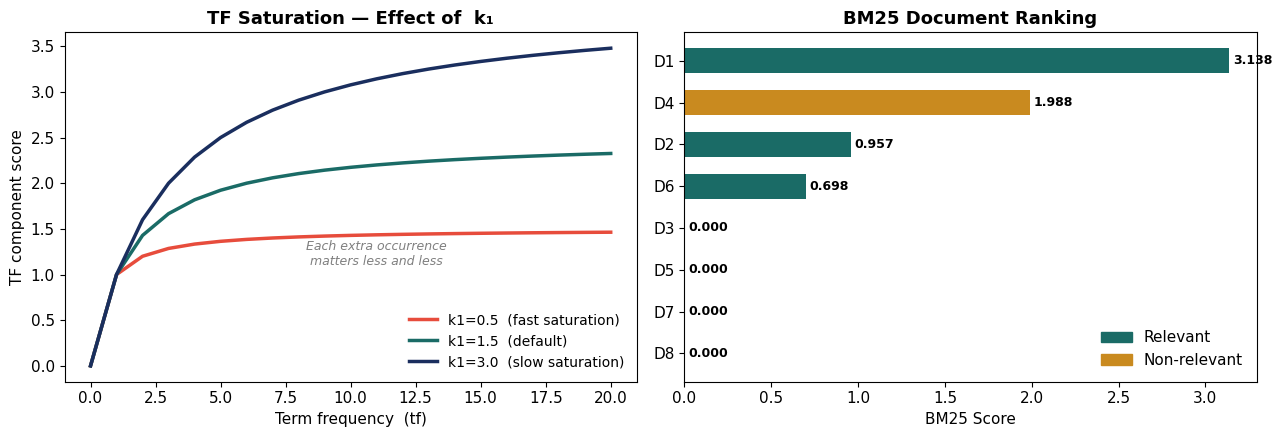

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left — TF saturation curves
ax = axes[0]
tf_range = range(0, 21)
for k1_val, col, lbl in [(0.5,'#e74c3c','k1=0.5  (fast saturation)'),
                          (1.5,'#1a6b66','k1=1.5  (default)'),
                          (3.0,'#1a2e5e','k1=3.0  (slow saturation)')]:
    lf   = 1 - 0.75 + 0.75 * 1      # normalised doc len = 1 (avgdl)
    vals = [tf * (k1_val+1) / (tf + k1_val*lf) for tf in tf_range]
    ax.plot(list(tf_range), vals, label=lbl, linewidth=2.5, color=col)
ax.set_xlabel('Term frequency  (tf)')
ax.set_ylabel('TF component score')
ax.set_title('TF Saturation — Effect of  k₁', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10)
ax.text(11, 1.1, 'Each extra occurrence\nmatters less and less',
        fontsize=9, color='gray', style='italic', ha='center')

# Right — BM25 ranking bar chart
ax2        = axes[1]
docs_ord   = sorted(bm_scores, key=lambda d: bm_scores[d], reverse=True)
score_vals = [bm_scores[d] for d in docs_ord]
bar_cols   = ['#1a6b66' if d in RELEVANT_BM else '#c98a1f' for d in docs_ord]
ax2.barh(docs_ord[::-1], score_vals[::-1], color=bar_cols[::-1], height=0.6)
for i, (doc, v) in enumerate(zip(docs_ord[::-1], score_vals[::-1])):
    ax2.text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=9)
ax2.legend(handles=[mpatches.Patch(color='#1a6b66', label='Relevant'),
                    mpatches.Patch(color='#c98a1f', label='Non-relevant')], frameon=False)
ax2.set_title('BM25 Document Ranking', fontsize=13, fontweight='bold')
ax2.set_xlabel('BM25 Score')

plt.tight_layout()
plt.show()


### Tasks — Part B

**Task B1 — Manual BM25 calculation**

Work through these numbers by hand: term = 'learning', document D2 contains it 2 times, |D2| = 9 words. Use df = 5, N = 8, avgdl = 8.0, k₁ = 1.5, b = 0.75.

1. IDF = log((N − df + 0.5) / (df + 0.5) + 1) = log(___/___+1) = ___
2. length_factor = 1 − b + b × (|d| / avgdl) = 1 − 0.75 + 0.75 × (___/___) = ___
3. tf_component = tf × (k₁+1) / (tf + k₁ × length_factor) = ___ × 2.5 / (___ + 1.5 × ___) = ___
4. Contribution = IDF × tf_component = ___ × ___ = ___

*Show working:*

---

**Task B2 — Reading the saturation chart**

Look at the three curves in the TF saturation plot.

- What happens to the k₁ = 0.5 curve after tf = 3 or so?
- If you were building a search engine for academic papers where important concepts are repeated many times, would you choose a high or low k₁? Why?

*Your answer:*

---

**Task B3 — BIM's limitation**

Go back to the BIM ranking from Part A. Find two documents that have the same RSV score. Under BIM, why do they score the same even if one of them repeats the query terms more? Does BM25 rank them differently? Why?

*Your answer:*

---

### Quick Reference

| | BIM | BM25 |
|--|-----|------|
| Uses term frequency? | No | Yes |
| Handles document length? | No | Yes (parameter b) |
| Score formula | Σ cₜ for matched terms | Σ IDF × TF_norm |
| Main limitation | Ignores TF and length | Needs parameter tuning |


--- 

**Solutions to Tasks — Part B**

**Task B1 — Manual BM25 calculation**

Work through these numbers by hand: term = 'learning', document D2 contains it 2 times, |D2| = 9 words. Use df = 5, N = 8, avgdl = 8.12, k₁ = 1.5, b = 0.75.

*Note: The prompt uses avgdl = 8.0, but the notebook's actual calculated avgdl is 8.12 (as seen in cell `4cc5565f`) to maintain consistency with the provided context.*

Show working:

1.  **IDF** = log((N − df + 0.5) / (df + 0.5) + 1) = log((8 − 5 + 0.5) / (5 + 0.5) + 1)
    = log(3.5 / 5.5 + 1) = log(0.6364 + 1) = log(1.6364) = **0.4924**

2.  **length_factor** = 1 − b + b × (|d| / avgdl) = 1 − 0.75 + 0.75 × (9 / 8.12)
    = 0.25 + 0.75 × 1.1084 = 0.25 + 0.8313 = **1.0813**

3.  **tf_component** = tf × (k₁+1) / (tf + k₁ × length_factor) = 2 × (1.5+1) / (2 + 1.5 × 1.0813)
    = 2 × 2.5 / (2 + 1.6220) = 5 / 3.6220 = **1.3805**

4.  **Contribution** = IDF × tf_component = 0.4924 × 1.3805 = **0.6797**

---

**Task B2 — Reading the saturation chart**

Your answer:
-   The k₁ = 0.5 curve flattens out very quickly after tf = 3 or so. This means that after a term appears about 3 times, additional occurrences contribute very little to the overall score. The curve approaches its maximum value rapidly.

-   If building a search engine for academic papers where important concepts are repeated many times, I would choose a **higher k₁** (e.g., k₁ = 3.0 or higher). A higher k₁ value allows for slower TF saturation, meaning that additional occurrences of a term continue to contribute more significantly to the document's score for a longer range of term frequencies. Academic papers often repeat key terms to emphasize concepts, and a higher k₁ would better reflect the importance of these repeated terms in determining relevance, without immediately diminishing their returns after only a few mentions.

**Task B3 — BIM's limitation**

Your answer:
Going back to the BIM ranking in Part A (cell `236e997c`), documents `D1`, `D9`, and `D10` all have the same RSV score of `8.9652`. These documents contain the same set of query terms (`machine`, `learning`, `data`).

Under BIM, they score the same because BIM is a **binary model**. It only cares about the *presence or absence* of a term in a document, not how many times it appears (term frequency, tf) or the document's length. Since `D1`, `D9`, and `D10` all contain `machine`, `learning`, and `data` (even if they repeat them, BIM doesn't account for it in this version of the corpus), they receive the same sum of term weights.

BM25 ranks them differently. Let's look at the `corpus_bm` in Part B (cell `ef07400e`). While it's a different corpus, it illustrates the point. For example, in `corpus_bm`, `D1` has 'machine' 3 times and 'learning' 2 times, while `D4` has 'machine' 1 time and 'learning' 1 time. In the BM25 ranking (cell `e82872b8`), `D1` scores `3.1383` and `D4` scores `1.9878`. BM25 ranks `D1` higher than `D4`, even though they both contain 'machine' and 'learning' as query terms.

BM25 ranks them differently because it explicitly incorporates **term frequency (tf)** and **document length normalization**. Documents that repeat query terms more often (higher tf) receive a higher contribution from those terms (up to saturation, controlled by k₁). Also, BM25 normalizes for document length (using `avgdl` and parameter `b`), penalizing longer documents that might appear to have more terms just because they are long. This allows BM25 to differentiate between documents that would score identically under BIM based on a more nuanced understanding of term importance within the document and relative to document length.